# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [53]:
df = pd.read_csv('data/vehicles.csv')
df

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy


In [54]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [55]:
null_pct = (df.isnull().sum() / len(df)) * 100
print(null_pct.sort_values(ascending=False))

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
id               0.000000
region           0.000000
price            0.000000
state            0.000000
dtype: float64


In [56]:
print(df['price'].describe())
print(f"\nCoches con precio = 0: {(df['price'] == 0).sum()}")
print(f"Coches con precio > 100,000: {(df['price'] > 100000).sum()}")

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

Coches con precio = 0: 32895
Coches con precio > 100,000: 655


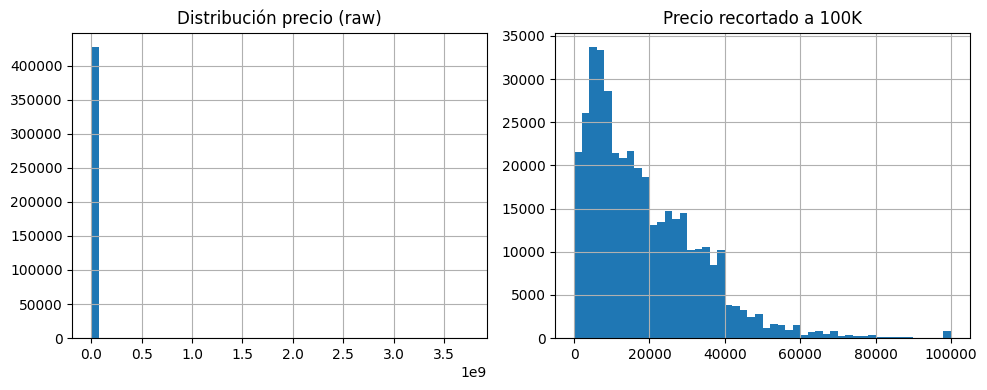

In [57]:
# Visualizar distribución
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['price'].hist(bins=50)
plt.title('Distribución precio (raw)')

plt.subplot(1,2,2)
df[df['price'] > 0]['price'].clip(upper=100000).hist(bins=50)
plt.title('Precio recortado a 100K')
plt.tight_layout()
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [58]:
# Deletting outliers
df_clean = df[(df['price'] >= 500) & (df['price'] <= 100000)]

In [59]:
print(f"Original total rows: {len(df)}")
print(f"New total rows: {len(df_clean)}")
print(f"Delete Rows: {len(df) - len(df_clean)}")
print(f"\nNew price describe:")
print(df_clean['price'].describe())

Original total rows: 426880
New total rows: 384131
Delete Rows: 42749

New price describe:
count    384131.000000
mean      19161.445457
std       14412.286474
min         500.000000
25%        7800.000000
50%       15900.000000
75%       27990.000000
max      100000.000000
Name: price, dtype: float64


In [60]:
# Deleting irrelevant attributes
df_clean = df_clean.drop(columns=['id', 'VIN', 'size', 'region'])


In [61]:
# Deletting null values in relevant attributes
df_clean = df_clean.dropna(subset=['year', 'odometer', 'fuel', 'transmission', 'title_status'])


In [62]:
# Filling null values with 'Unknown' for categorical attributes
cols_fill = ['manufacturer', 'model', 'condition', 'cylinders', 'drive', 'paint_color', 'type']
df_clean[cols_fill] = df_clean[cols_fill].fillna('unknown')

In [63]:
print(f"Total Files: {len(df_clean)}")
print(f"Columns: {df_clean.columns.tolist()}")
print(f"\nNull values after cleaning:")
print(df_clean.isnull().sum())

Total Files: 371400
Columns: ['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']

Null values after cleaning:
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64


In [64]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 371400 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         371400 non-null  int64  
 1   year          371400 non-null  float64
 2   manufacturer  371400 non-null  object 
 3   model         371400 non-null  object 
 4   condition     371400 non-null  object 
 5   cylinders     371400 non-null  object 
 6   fuel          371400 non-null  object 
 7   odometer      371400 non-null  float64
 8   title_status  371400 non-null  object 
 9   transmission  371400 non-null  object 
 10  drive         371400 non-null  object 
 11  type          371400 non-null  object 
 12  paint_color   371400 non-null  object 
 13  state         371400 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 42.5+ MB


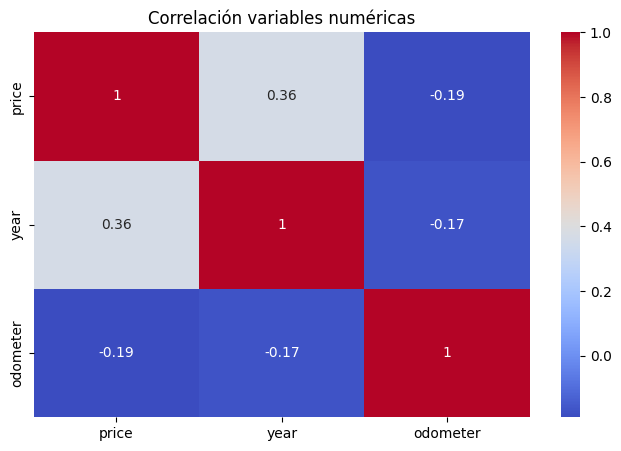

In [65]:
# Numerical attributes correlation
plt.figure(figsize=(8,5))
numeric_cols = df_clean[['price', 'year', 'odometer']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlación variables numéricas')
plt.show()

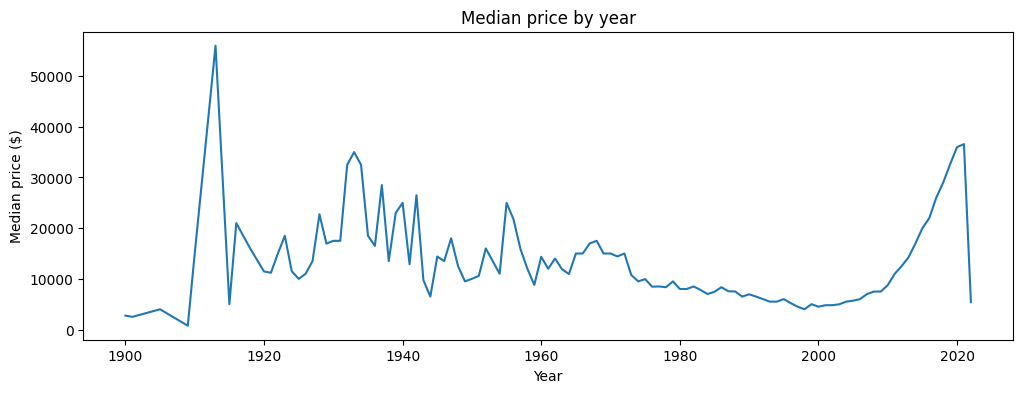

In [66]:
# Price per year
plt.figure(figsize=(12,4))
df_clean.groupby('year')['price'].median().plot()
plt.title('Median price by year')
plt.xlabel('Year')
plt.ylabel('Median price ($)')
plt.show()

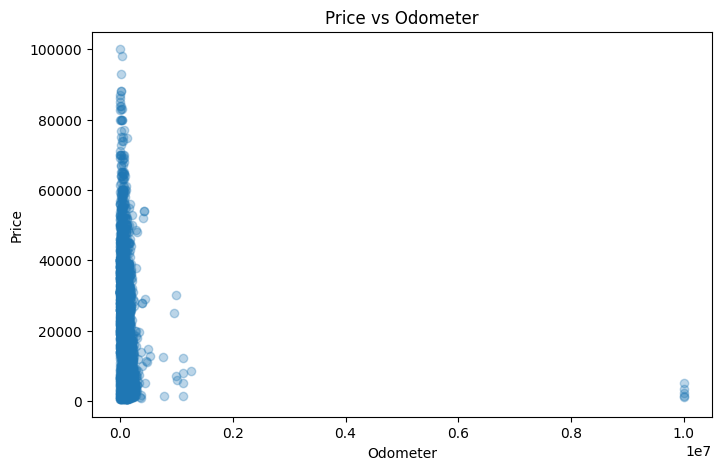

In [67]:
# Price vs Odometer
plt.figure(figsize=(8,5))
sample = df_clean.sample(5000)
plt.scatter(sample['odometer'], sample['price'], alpha=0.3)
plt.title('Price vs Odometer')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.show()

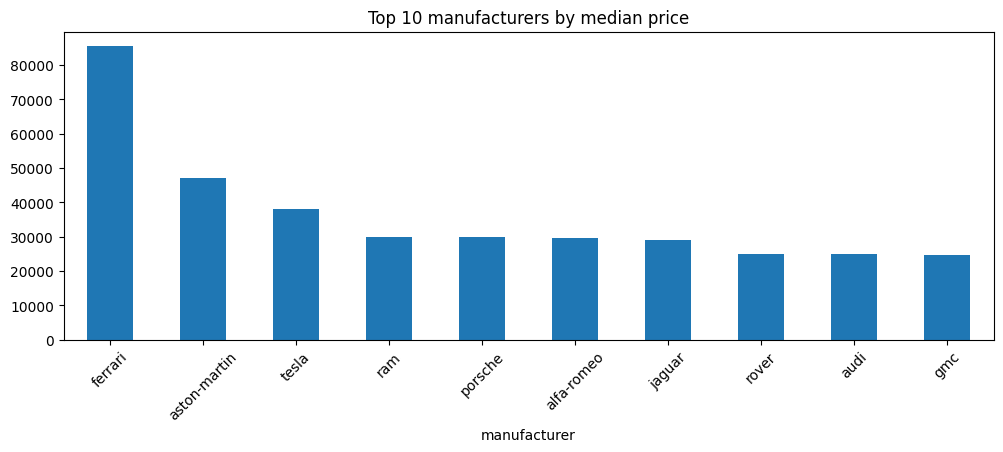

In [68]:
# 4. Top 10 manufacturers by median price
plt.figure(figsize=(12,4))
top_manufacturers = df_clean.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(10)
top_manufacturers.plot(kind='bar')
plt.title('Top 10 manufacturers by median price')
plt.xticks(rotation=45)
plt.show()

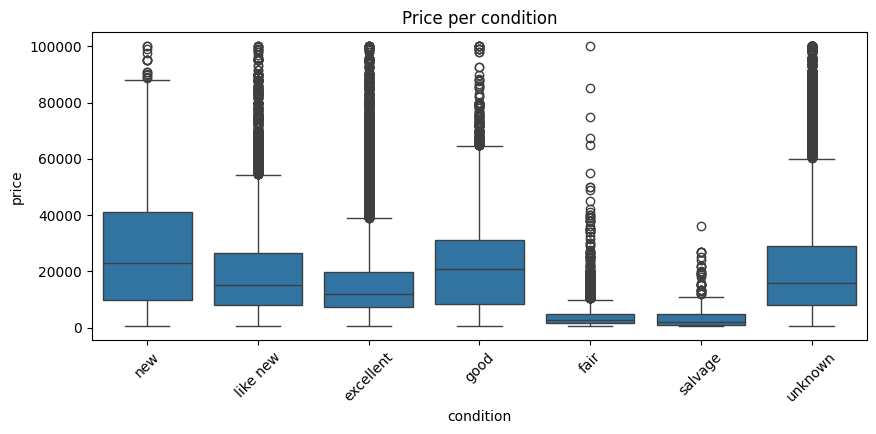

In [69]:
# Price per condition
plt.figure(figsize=(10,4))
order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage', 'unknown']
sns.boxplot(data=df_clean, x='condition', y='price', order=order)
plt.title('Price per condition')
plt.xticks(rotation=45)
plt.show()


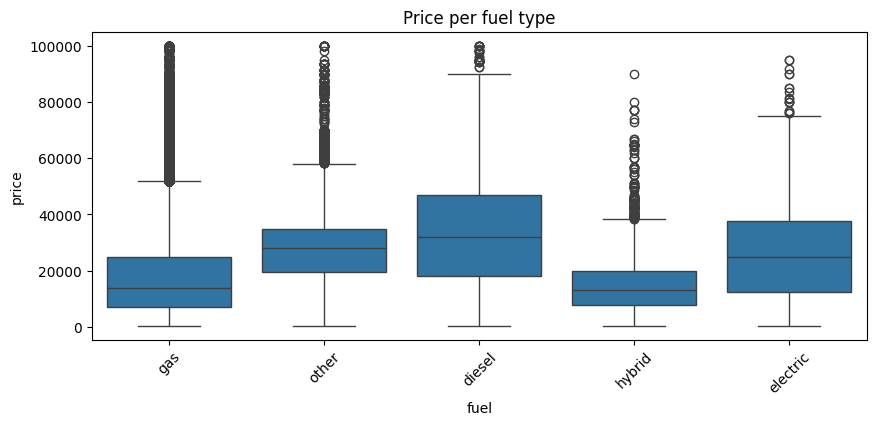

In [70]:
# Price per fuel type
plt.figure(figsize=(10,4))
sns.boxplot(data=df_clean, x='fuel', y='price')
plt.title('Price per fuel type')
plt.xticks(rotation=45)
plt.show()

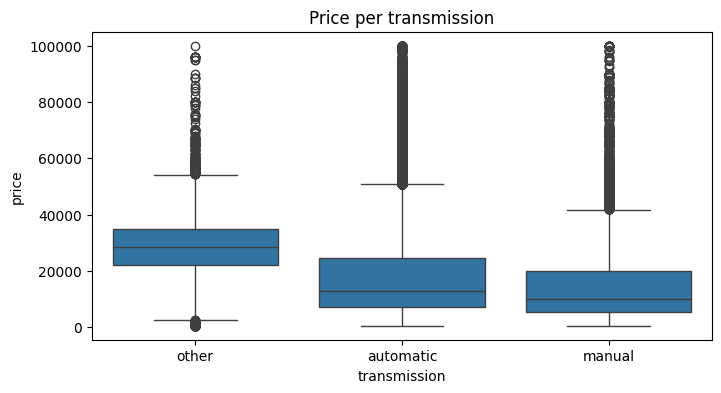

In [71]:
# Price per transmission
plt.figure(figsize=(8,4))
sns.boxplot(data=df_clean, x='transmission', y='price')
plt.title('Price per transmission')
plt.show()

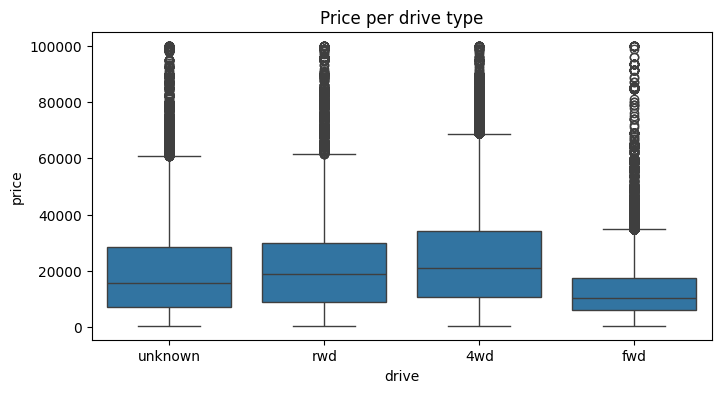

In [72]:
# Price per drive type
plt.figure(figsize=(8,4))
sns.boxplot(data=df_clean, x='drive', y='price')
plt.title('Price per drive type')
plt.show()

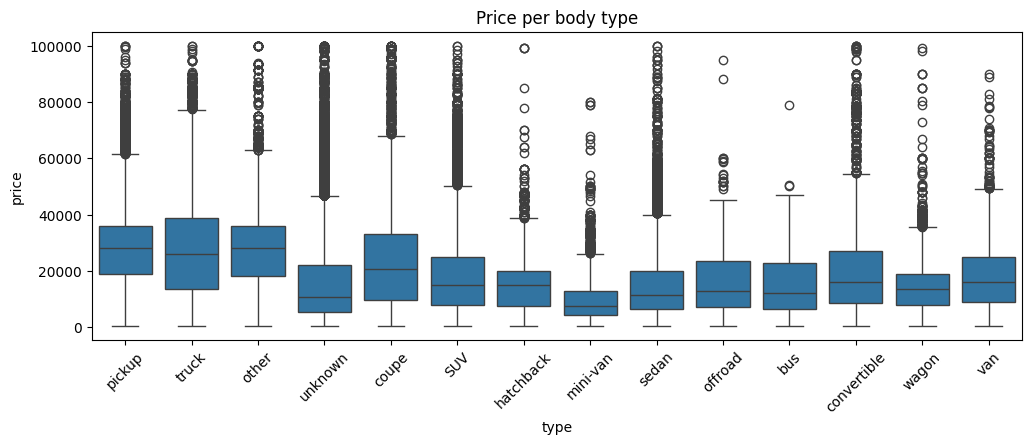

In [73]:
# Price per body type
plt.figure(figsize=(12,4))
sns.boxplot(data=df_clean, x='type', y='price')
plt.title('Price per body type')
plt.xticks(rotation=45)
plt.show()

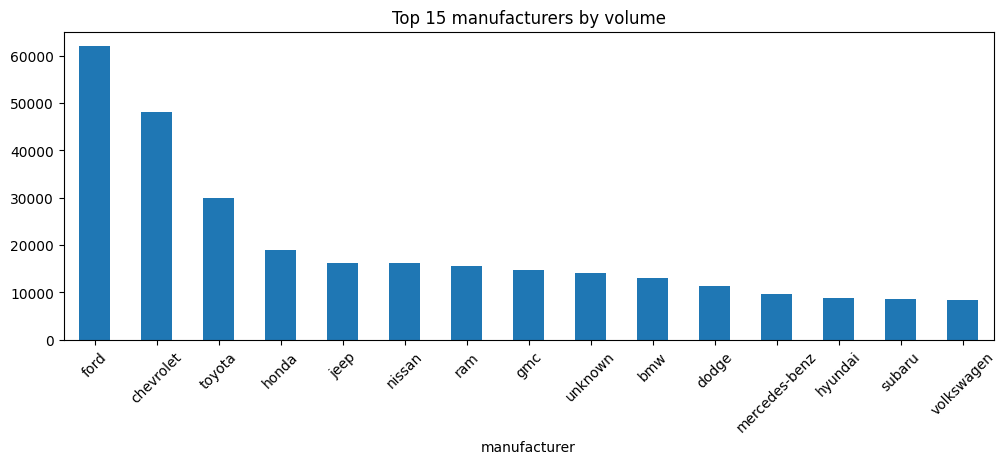

In [74]:
# Top 15 manufacturers by volume
plt.figure(figsize=(12,4))
df_clean['manufacturer'].value_counts().head(15).plot(kind='bar')
plt.title('Top 15 manufacturers by volume')
plt.xticks(rotation=45)
plt.show()

In [75]:
# Filtrar años raros y odómetro extremo
print(f"Año mínimo: {df_clean['year'].min()}")
print(f"Año máximo: {df_clean['year'].max()}")
print(f"Odómetro máximo: {df_clean['odometer'].max()}")
print(f"Odómetro percentil 99%: {df_clean['odometer'].quantile(0.99)}")

Año mínimo: 1900.0
Año máximo: 2022.0
Odómetro máximo: 10000000.0
Odómetro percentil 99%: 281000.0


Filas finales: 357349


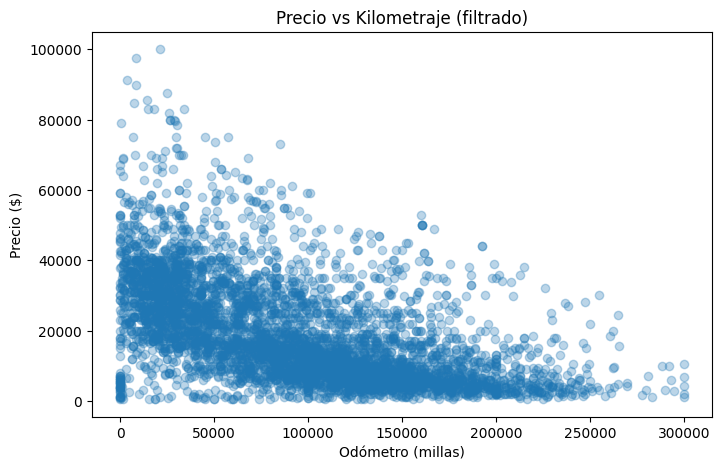

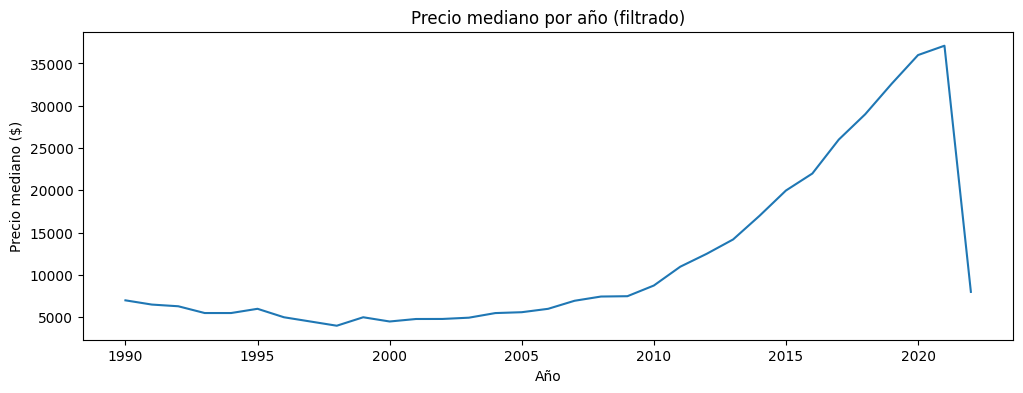

In [76]:
# Filtrar años y odómetro
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2022)]
df_clean = df_clean[df_clean['odometer'] <= 300000]

print(f"Filas finales: {len(df_clean)}")

# Repetir scatter odómetro con escala correcta
plt.figure(figsize=(8,5))
sample = df_clean.sample(5000)
plt.scatter(sample['odometer'], sample['price'], alpha=0.3)
plt.title('Precio vs Kilometraje (filtrado)')
plt.xlabel('Odómetro (millas)')
plt.ylabel('Precio ($)')
plt.show()

# Repetir gráfico de precio por año
plt.figure(figsize=(12,4))
df_clean.groupby('year')['price'].median().plot()
plt.title('Precio mediano por año (filtrado)')
plt.xlabel('Año')
plt.ylabel('Precio mediano ($)')
plt.show()

In [77]:
# Remove remaining suspicious entries
df_clean = df_clean[df_clean['odometer'] > 1000]

print(f"Final rows: {len(df_clean)}")
print(f"\nFinal dataset summary:")
print(df_clean.describe())

Final rows: 351167

Final dataset summary:
               price           year       odometer
count  351167.000000  351167.000000  351167.000000
mean    19230.755205    2012.265298   94494.670234
std     14181.609371       5.795632   61376.823147
min       500.000000    1990.000000    1001.000000
25%      7950.000000    2009.000000   40784.000000
50%     15990.000000    2013.000000   90000.000000
75%     27990.000000    2017.000000  137369.000000
max    100000.000000    2022.000000  300000.000000


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [78]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [79]:
# Encode categorical variables
df_model = df_clean.copy()
categorical_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 
                    'title_status', 'transmission', 'drive', 'type', 
                    'paint_color', 'state']
le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [81]:
# Drop model column (too many unique values)
df_model = df_model.drop(columns=['model'])

In [82]:
# Define features and target
X = df_model.drop(columns=['price'])
y = df_model['price']

In [83]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nFeatures: {X.columns.tolist()}")

Training set: (280933, 12)
Test set: (70234, 12)

Features: ['year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


In [84]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Helper function to evaluate models
def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE:  ${mae:,.0f}")
    print(f"  R²:   {r2:.3f}")
    return rmse, mae, r2

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, y_pred_lr)

# 2. Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)

# 3. Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
evaluate_model("Lasso Regression", y_test, y_pred_lasso)


Linear Regression
  RMSE: $10,016
  MAE:  $7,399
  R²:   0.499

Ridge Regression
  RMSE: $10,016
  MAE:  $7,399
  R²:   0.499

Lasso Regression
  RMSE: $10,016
  MAE:  $7,399
  R²:   0.499


(np.float64(10016.425621609465), 7399.320643231616, 0.4992547863390612)

In [85]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Define column types
numeric_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 
                        'title_status', 'transmission', 'drive', 'type', 
                        'paint_color', 'state']

# Proper preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training Random Forest... (may take a few minutes)")
rf_pipeline.fit(X_train[numeric_features + categorical_features], y_train)
y_pred_rf = rf_pipeline.predict(X_test[numeric_features + categorical_features])
evaluate_model("Random Forest", y_test, y_pred_rf)

Training Random Forest... (may take a few minutes)

Random Forest
  RMSE: $4,258
  MAE:  $1,942
  R²:   0.910


(np.float64(4257.9732671079), 1942.152687590696, 0.9095107212114062)

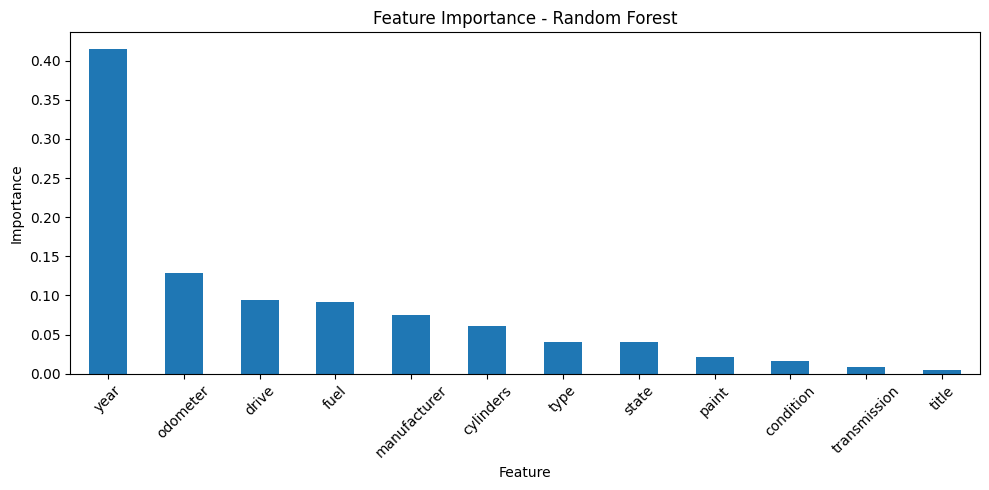

original_col
year            0.415438
odometer        0.128941
drive           0.094217
fuel            0.092189
manufacturer    0.075146
cylinders       0.061291
type            0.040727
state           0.040710
paint           0.020970
condition       0.016904
transmission    0.008080
title           0.005385
Name: importance, dtype: float64


In [86]:
# Extract feature importances
ohe_features = rf_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_features = numeric_features + list(ohe_features)
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create importance dataframe
feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

# Group by original column
feat_imp['original_col'] = feat_imp['feature'].apply(lambda x: x.split('_')[0])
feat_imp_grouped = feat_imp.groupby('original_col')['importance'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,5))
feat_imp_grouped.plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(feat_imp_grouped)

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.